c:\Users\taoji\anaconda3\Lib\site-packages\kwant\lattice.py:120: KwantDeprecationWarning: Not specfying norbs is deprecated. Always specify norbs when creating site families.
  self.sublattices = [Monatomic(prim_vecs, offset, sname, norb)


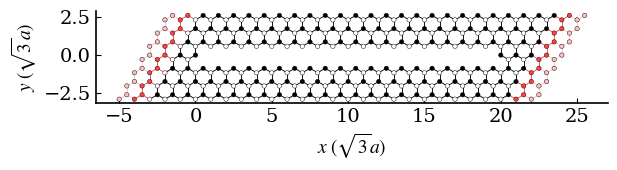

In [2]:
# ============================================================
#  Graphene ribbon with two leads
#  Scattering region with a central gap |y| < 0.5 removed
#  Magnetic field: A = (B y, 0, 0)
# ============================================================

import kwant
import numpy as np
import matplotlib.pyplot as plt
import os


# ============================================================
#  1. Global parameters
# ============================================================
t = 1.0
L = 20        # ribbon length (x direction)
W = 3         # half width |y| <= W
B = 0.1       # magnetic field strength


# ============================================================
#  2. Output directory
# ============================================================
out_dir = r"D:\结果\作业"
os.makedirs(out_dir, exist_ok=True)


# ============================================================
#  3. Lattice
# ============================================================
graphene = kwant.lattice.honeycomb()
a, b = graphene.sublattices


# ============================================================
#  4. Scattering region (with central gap removed)
# ============================================================
def ribbon_shape(pos):
    x, y = pos

    # 基本 ribbon
    if not ((0 <= x <= L) and (abs(y) <= W)):
        return False

    # ===============================
    # 在散射区内部挖掉 y∈[-0.5,0.5]
    # 注意：不碰导线接口 x=0, x=L
    # ===============================
    if (0 < x < L) and (abs(y) < 0.5):
        return False

    return True



def peierls_hopping(site_i, site_j, B):
    xi, yi = site_i.pos
    xj, yj = site_j.pos
    phase = B * (yi + yj) / 2 * (xj - xi)
    return -t * np.exp(1j * phase)


def make_scattering_region():
    syst = kwant.Builder()
    syst[graphene.shape(ribbon_shape, (0, W))] = 0.0
    syst[graphene.neighbors()] = peierls_hopping
    return syst


# ============================================================
#  5. Leads (no magnetic field, no gap)
# ============================================================
def lead_shape(pos):
    x, y = pos
    return abs(y) <= W


def make_leads():
    sym_left = kwant.TranslationalSymmetry((-1, 0))
    lead_left = kwant.Builder(sym_left)
    lead_left[graphene.shape(lead_shape, (0, 0))] = 0.0
    lead_left[graphene.neighbors()] = -t

    sym_right = kwant.TranslationalSymmetry((1, 0))
    lead_right = kwant.Builder(sym_right)
    lead_right[graphene.shape(lead_shape, (0, 0))] = 0.0
    lead_right[graphene.neighbors()] = -t

    return lead_left, lead_right


# ============================================================
#  6. Build system
# ============================================================
def make_system():
    syst = make_scattering_region()
    lead_left, lead_right = make_leads()
    syst.attach_lead(lead_left)
    syst.attach_lead(lead_right)
    return syst


# ============================================================
#  7. Plot system structure
# ============================================================
if __name__ == "__main__":

    syst = make_system()

    plt.rcParams.update({
        "font.family": "serif",
        "mathtext.fontset": "stix",
        "font.size": 14,
        "axes.linewidth": 1.2,
        "xtick.direction": "in",
        "ytick.direction": "in",
    })

    fig = kwant.plot(
        syst,
        site_color=lambda site: "black" if site.family == a else "white",
        site_edgecolor="black",
        site_lw=0.05,
        hop_color="black",
        hop_lw=0.1,
        show=False
    )

    ax = plt.gca()
    ax.set_xlabel(r"$x\;(\sqrt{3}a)$")
    ax.set_ylabel(r"$y\;(\sqrt{3}a)$")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()
    fig.savefig(os.path.join(out_dir, "graphene_gap_scattering_region.pdf"))
    fig.savefig(os.path.join(out_dir, "graphene_gap_scattering_region.png"), dpi=600)

    plt.show()


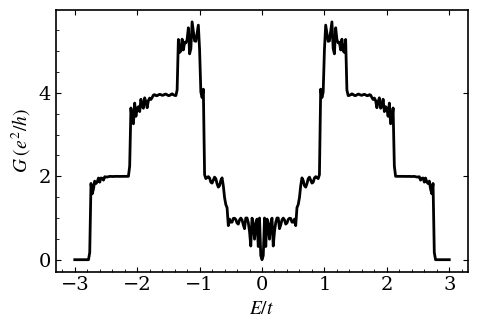

In [3]:
# ============================================================
#  8. Conductance
# ============================================================

fsyst = syst.finalized()

energies = np.linspace(-3, 3, 301)
conductance = []

for E in energies:
    try:
        smatrix = kwant.smatrix(fsyst, energy=E, params=dict(B=B))
        G = smatrix.transmission(1, 0)
    except Exception:
        G = 0.0
    conductance.append(G)

plt.figure(figsize=(5, 3.5))
plt.plot(energies, conductance, lw=2, color="black")

plt.xlabel(r"$E/t$")
plt.ylabel(r"$G\;(e^2/h)$")

plt.minorticks_on()
plt.tick_params(direction="in", top=True, right=True)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, "conductance_gap_B.pdf"))
plt.savefig(os.path.join(out_dir, "conductance_gap_B.png"), dpi=600)
plt.show()


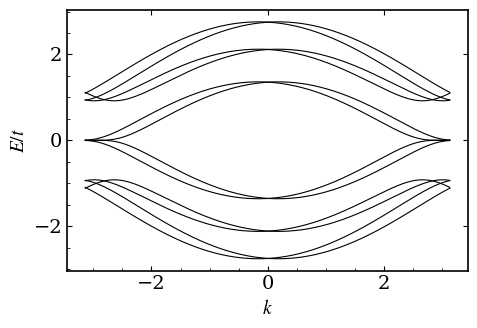

In [4]:
# ============================================================
#  9. Infinite ribbon with gap & B field: band structure
# ============================================================

def infinite_shape(pos):
    x, y = pos

    # 横向无限，只限制 y
    if abs(y) > W:
        return False

    # 挖掉中间 |y| < 0.5
    if abs(y) < 0.5:
        return False

    return True


def make_infinite_system():
    sym = kwant.TranslationalSymmetry((1, 0))
    syst = kwant.Builder(sym)

    syst[graphene.shape(infinite_shape, (0, W))] = 0.0
    syst[graphene.neighbors()] = peierls_hopping

    return syst


# ---------- compute bands ----------
inf_syst = make_infinite_system().finalized()

bands = kwant.physics.Bands(inf_syst, params=dict(B=B))
k_vals = np.linspace(-np.pi, np.pi, 401)

energies_bands = [bands(k) for k in k_vals]

plt.figure(figsize=(5, 3.5))
for n in range(len(energies_bands[0])):
    plt.plot(k_vals, [e[n] for e in energies_bands],
             color="black", lw=0.8)

plt.xlabel(r"$k$")
plt.ylabel(r"$E/t$")

plt.minorticks_on()
plt.tick_params(direction="in", top=True, right=True)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, "bands_gap_B.pdf"))
plt.savefig(os.path.join(out_dir, "bands_gap_B.png"), dpi=600)
plt.show()


C:\Users\taoji\AppData\Local\Temp\ipykernel_29788\2027177198.py:13: RuntimeWarning:

The plotted data contains 0.94% of values overflowing upper limit 3.8866 



<Figure size 500x400 with 0 Axes>

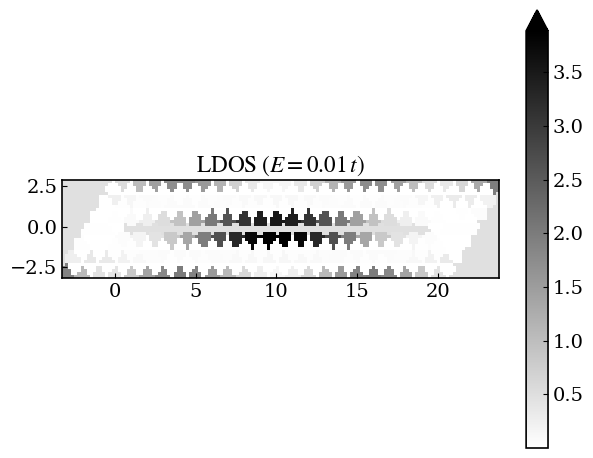

In [8]:
# ============================================================
#  LDOS at fixed energy (no colorbar modification)
# ============================================================

energy_ldos = 0.01

fsyst = syst.finalized()

ldos = kwant.ldos(fsyst, energy=energy_ldos, params=dict(B=B))

plt.figure(figsize=(5, 4))

kwant.plotter.map(
    fsyst,
    ldos,
    colorbar=True,
    cmap="gray_r",
    show=False
)

plt.title(r"$\mathrm{LDOS}\;(E=0.01\,t)$")

plt.tight_layout()
plt.savefig(os.path.join(out_dir, "ldos_gap_B.pdf"))
plt.savefig(os.path.join(out_dir, "ldos_gap_B.png"), dpi=600)
plt.show()
